In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/nearest_neighbour.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/nearest_neighbour.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/nearest_neighbour.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/nearest_neighbour.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/nearest_neighbour.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/nearest_neighbour.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)


si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()


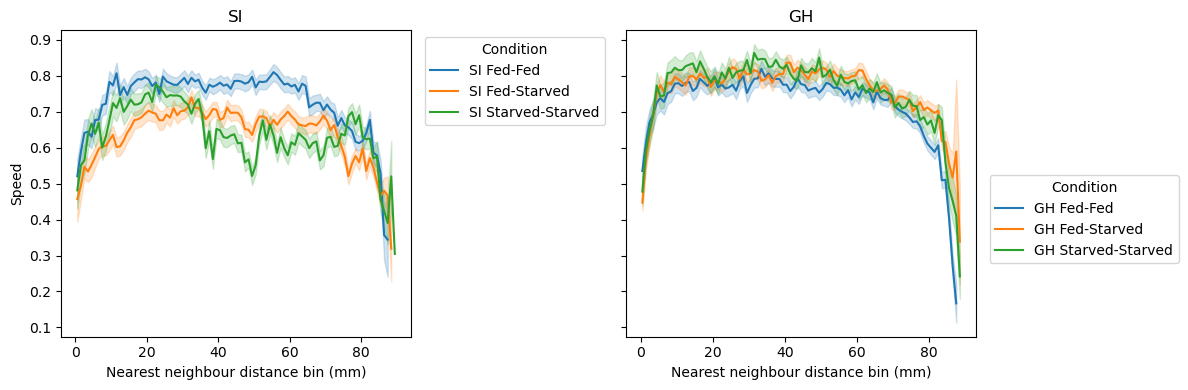

In [3]:
# 1 mm bins from 0 to 90
df['distance_bin'] = pd.cut(
    df['head_distance'],
    bins=np.arange(0, 91, 1),
    include_lowest=True
)

df['distance_bin_center'] = df['distance_bin'].apply(lambda x: x.mid)

# recreate SI/GH after adding bins
si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# SI
sns.lineplot(
    data=si,
    x='distance_bin_center',
    y='speed',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('SI')
axes[0].set_xlabel('Nearest neighbour distance bin (mm)')
axes[0].set_ylabel('Speed')

sns.lineplot(
    data=gh,
    x='distance_bin_center',
    y='speed',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('GH')
axes[1].set_xlabel('Nearest neighbour distance bin (mm)')
axes[1].set_ylabel('')

sns.move_legend(axes[0], "upper left", bbox_to_anchor=(1.02, 1))
sns.move_legend(axes[1], "upper left", bbox_to_anchor=(1.02, 0.55))

plt.tight_layout()
plt.show()

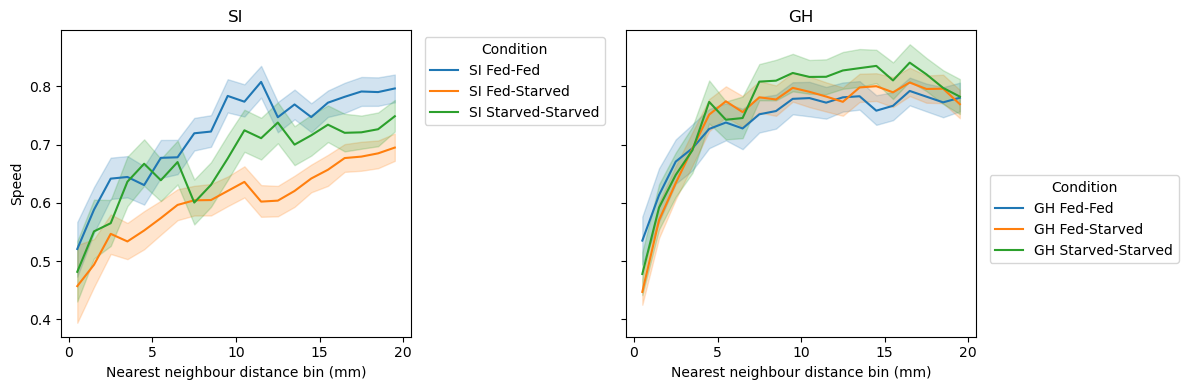

In [4]:


df_20 = df[df['head_distance'] < 20].copy()

df_20['distance_bin'] = pd.cut(
    df_20['head_distance'],
    bins=np.arange(0, 21, 1),
    include_lowest=True
)

df_20['distance_bin_center'] = df_20['distance_bin'].apply(lambda x: x.mid)

# recreate SI/GH after adding bins
si = df_20[df_20['Condition'].str.contains('SI')].copy()
gh = df_20[df_20['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# SI
sns.lineplot(
    data=si,
    x='distance_bin_center',
    y='speed',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('SI')
axes[0].set_xlabel('Nearest neighbour distance bin (mm)')
axes[0].set_ylabel('Speed')

sns.lineplot(
    data=gh,
    x='distance_bin_center',
    y='speed',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('GH')
axes[1].set_xlabel('Nearest neighbour distance bin (mm)')
axes[1].set_ylabel('')

sns.move_legend(axes[0], "upper left", bbox_to_anchor=(1.02, 1))
sns.move_legend(axes[1], "upper left", bbox_to_anchor=(1.02, 0.55))

plt.tight_layout()
plt.show()

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_41581/462616442.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


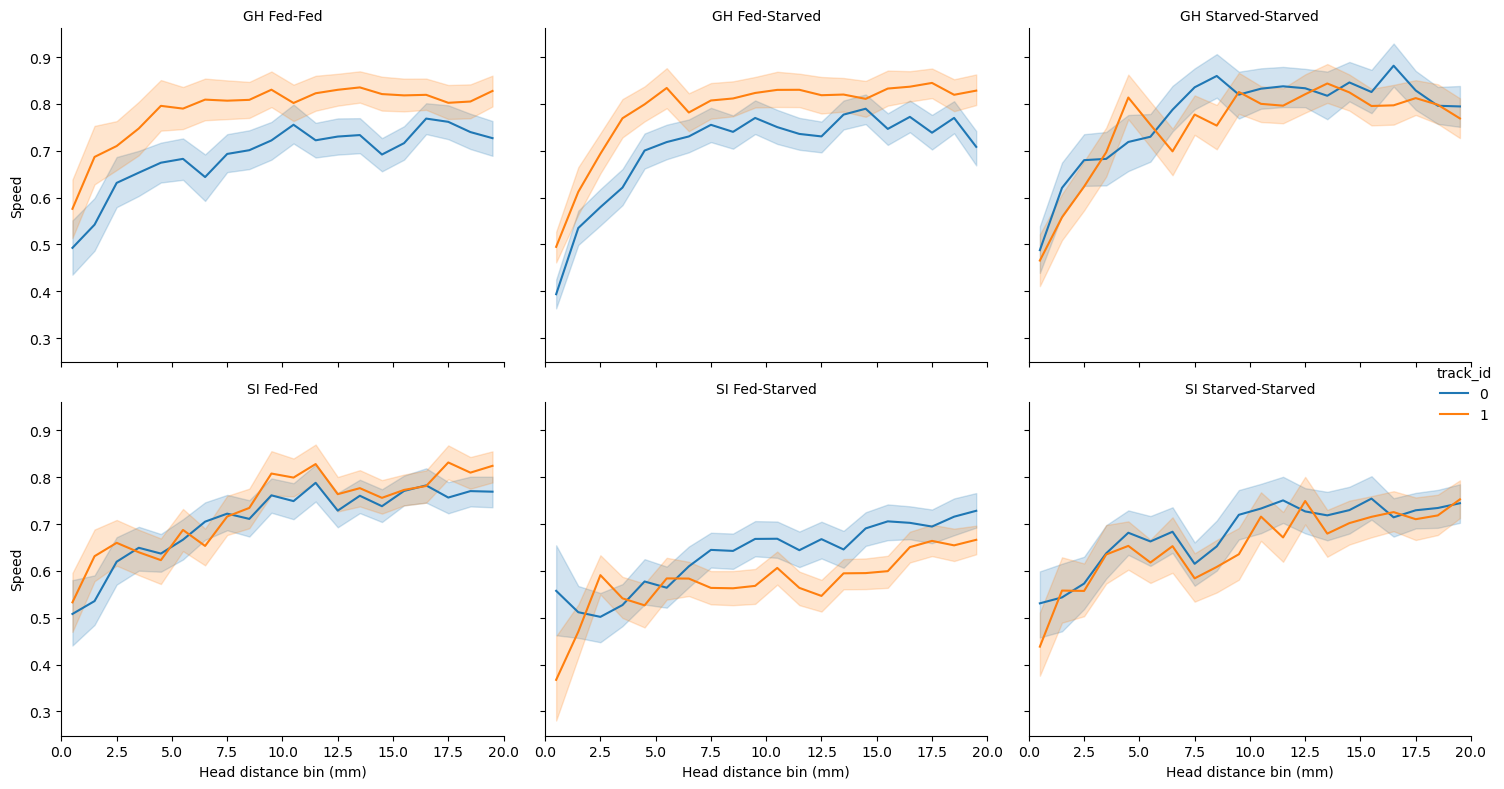

In [5]:
# filter first
df_20 = df[df['head_distance'] < 20].copy()

# 1 mm bins
df_20['distance_bin'] = pd.cut(
    df_20['head_distance'],
    bins=np.arange(0, 21, 1),
    include_lowest=True
)

df_20['distance_bin_center'] = (
    df_20['distance_bin']
      .apply(lambda x: x.mid)
)

g = sns.relplot(
    data=df_20,
    x='distance_bin_center',
    y='speed',
    hue='track_id',
    col='Condition',
    col_wrap=3,
    kind='line',
    errorbar=('ci', 95),
    height=4,
    aspect=1.2
)

g.set_axis_labels(
    'Head distance bin (mm)',
    'Speed'
)

g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.set_xlim(0, 20)

plt.tight_layout()
plt.show()

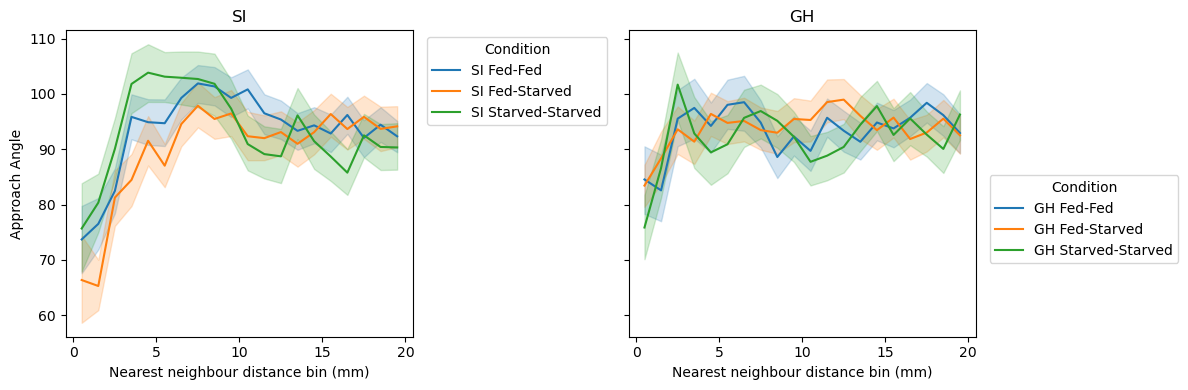

In [6]:

df_20['distance_bin'] = pd.cut(
    df_20['head_distance'],
    bins=np.arange(0, 91, 1),
    include_lowest=True
)

df_20['distance_bin_center'] = df_20['distance_bin'].apply(lambda x: x.mid)

# recreate SI/GH after adding bins
si = df_20[df_20['Condition'].str.contains('SI')].copy()
gh = df_20[df_20['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# SI
sns.lineplot(
    data=si,
    x='distance_bin_center',
    y='approach_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('SI')
axes[0].set_xlabel('Nearest neighbour distance bin (mm)')
axes[0].set_ylabel('Approach Angle')

sns.lineplot(
    data=gh,
    x='distance_bin_center',
    y='approach_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('GH')
axes[1].set_xlabel('Nearest neighbour distance bin (mm)')
axes[1].set_ylabel('')

sns.move_legend(axes[0], "upper left", bbox_to_anchor=(1.02, 1))
sns.move_legend(axes[1], "upper left", bbox_to_anchor=(1.02, 0.55))

plt.tight_layout()
plt.show()

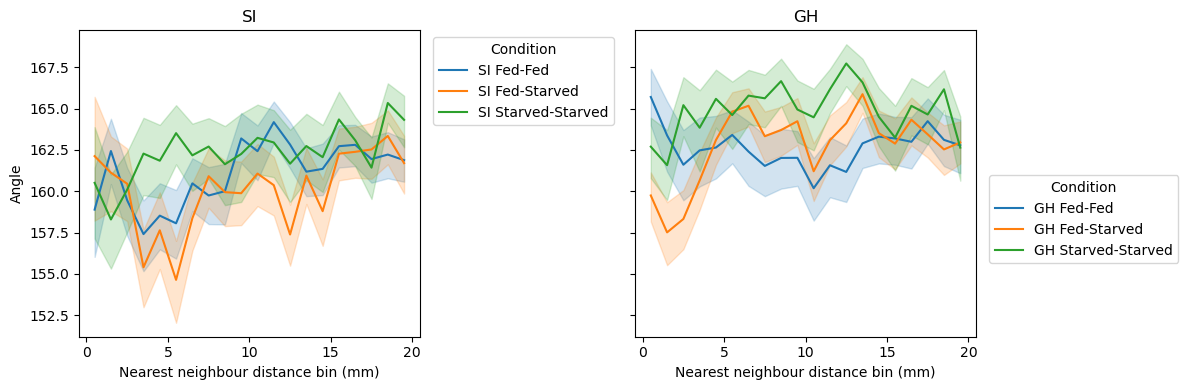

In [7]:

df_20['distance_bin'] = pd.cut(
    df_20['head_distance'],
    bins=np.arange(0, 91, 1),
    include_lowest=True
)

df_20['distance_bin_center'] = df_20['distance_bin'].apply(lambda x: x.mid)

# recreate SI/GH after adding bins
si = df_20[df_20['Condition'].str.contains('SI')].copy()
gh = df_20[df_20['Condition'].str.contains('GH')].copy()

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# SI
sns.lineplot(
    data=si,
    x='distance_bin_center',
    y='angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('SI')
axes[0].set_xlabel('Nearest neighbour distance bin (mm)')
axes[0].set_ylabel('Angle')

sns.lineplot(
    data=gh,
    x='distance_bin_center',
    y='angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('GH')
axes[1].set_xlabel('Nearest neighbour distance bin (mm)')
axes[1].set_ylabel('')

sns.move_legend(axes[0], "upper left", bbox_to_anchor=(1.02, 1))
sns.move_legend(axes[1], "upper left", bbox_to_anchor=(1.02, 0.55))

plt.tight_layout()
plt.show()

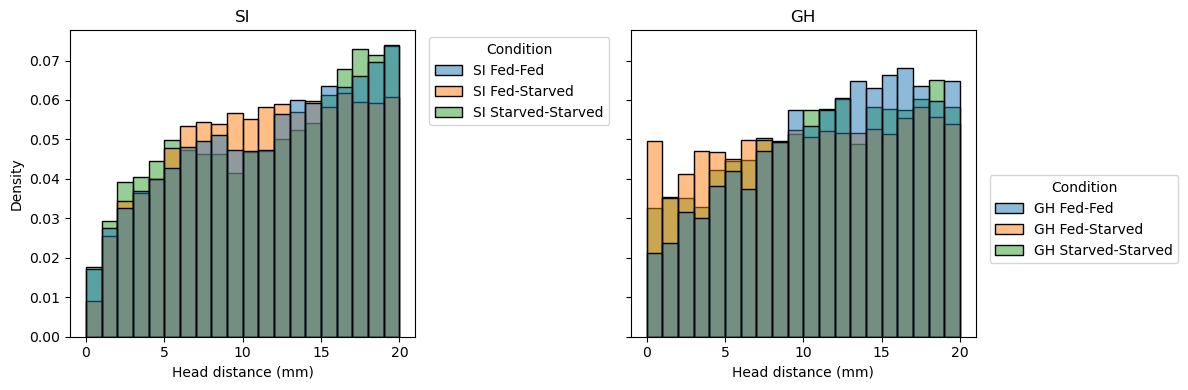

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# SI
sns.histplot(
    data=si,
    x='head_distance',
    hue='Condition',
    bins=np.arange(0, 21, 1),
    stat='density',
    common_norm=False,
    ax=axes[0]
)

axes[0].set_title('SI')
axes[0].set_xlabel('Head distance (mm)')
axes[0].set_ylabel('Density')

# GH
sns.histplot(
    data=gh,
    x='head_distance',
    hue='Condition',
    bins=np.arange(0, 21, 1),
    stat='density',
    common_norm=False,
    ax=axes[1]
)

axes[1].set_title('GH')
axes[1].set_xlabel('Head distance (mm)')
axes[1].set_ylabel('')

sns.move_legend(
    axes[0],
    "upper left",
    bbox_to_anchor=(1.02, 1)
)

sns.move_legend(
    axes[1],
    "upper left",
    bbox_to_anchor=(1.02, 0.55)
)

plt.tight_layout()
plt.show()

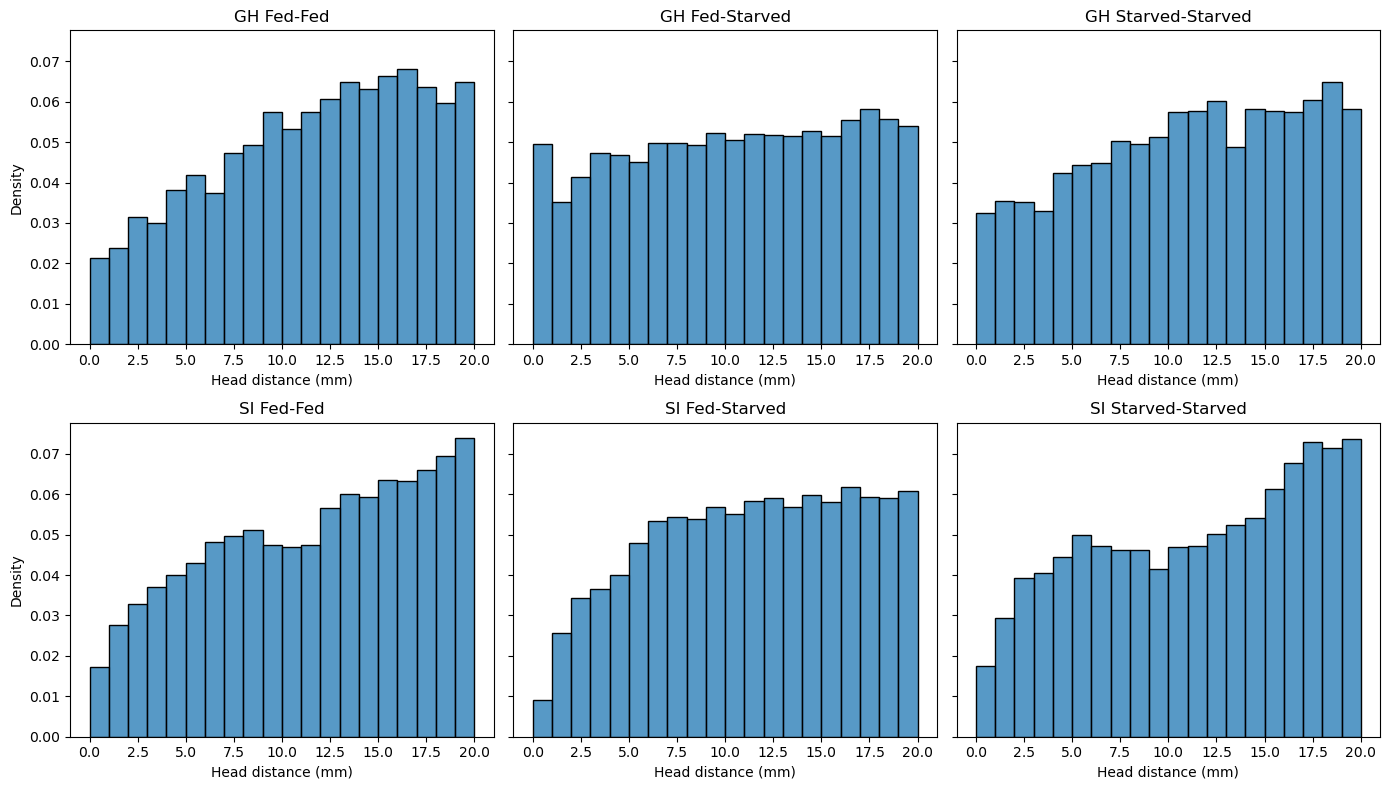

In [9]:
conditions = df['Condition'].unique()

fig, axes = plt.subplots(2, 3, figsize=(14,8), sharey=True)

axes = axes.flatten()

for ax, condition in zip(axes, conditions):

    subset = df[df['Condition'] == condition]

    sns.histplot(
        data=subset,
        x='head_distance',
        bins=np.arange(0, 21, 1),
        stat='density',
        common_norm=False,
        ax=ax
    )

    ax.set_title(condition)
    ax.set_xlabel('Head distance (mm)')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

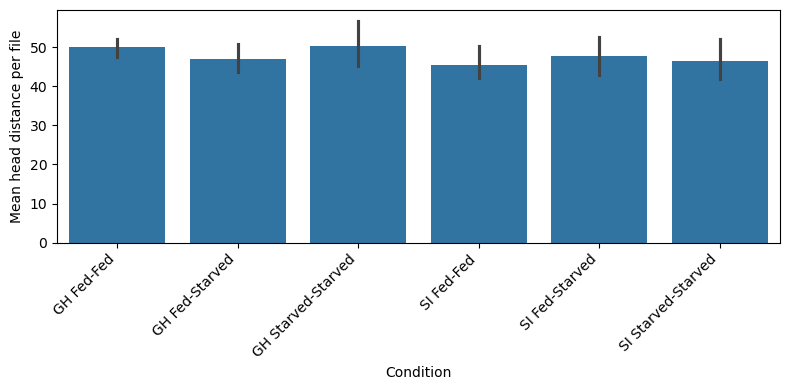

In [10]:
# mean head distance per file
head_distance_per_file = (
    df.groupby(['Condition', 'filename'])['head_distance']
      .mean()
      .reset_index(name='mean_head_distance')
)

plt.figure(figsize=(8,4))

sns.barplot(
    data=head_distance_per_file,
    x='Condition',
    y='mean_head_distance',
    errorbar=('ci', 95)
)



plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean head distance per file')
plt.xlabel('Condition')

plt.tight_layout()
plt.show()

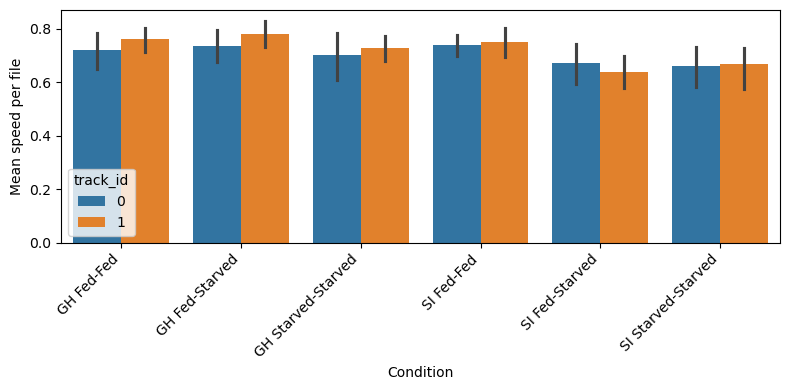

In [11]:
# mean head distance per file
head_distance_per_file = (
    df.groupby(['Condition', 'filename', 'track_id'])['speed']
      .mean()
      .reset_index(name='speed')
)

plt.figure(figsize=(8,4))

sns.barplot(
    data=head_distance_per_file,
    x='Condition',
    y='speed',
    hue='track_id',
    errorbar=('ci', 95)
)



plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean speed per file')
plt.xlabel('Condition')

plt.tight_layout()
plt.show()

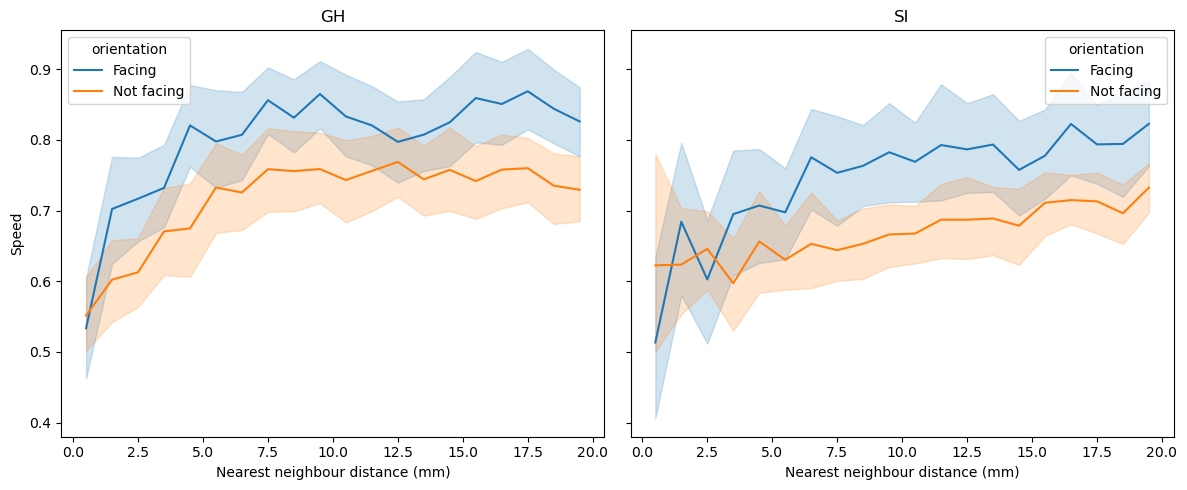

In [16]:
df_angle = df.copy()

df_angle = df[
    ((df['approach_angle'] < 30) |
     (df['approach_angle'] > 90))
].copy()

df_angle['orientation'] = np.where(
    df_angle['approach_angle'] < 30,
    'Facing',
    'Not facing'
)

df_angle['distance_bin'] = pd.cut(
    df_angle['head_distance'],
    bins=np.arange(0, 21, 1),
    include_lowest=True
)

speed_df = (
    df_angle
    .groupby(
        ['Condition', 'filename', 'orientation', 'distance_bin']
    )['speed']
    .mean()
    .reset_index()
)

speed_df['distance_midpoint'] = (
    speed_df['distance_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

gh = speed_df[speed_df['Condition'].str.contains('GH')]
si = speed_df[speed_df['Condition'].str.contains('SI')]




fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

sns.lineplot(
    data=gh,
    x='distance_midpoint',
    y='speed',
    hue='orientation',
    errorbar=('ci',95),
    ax=axes[0]
)

axes[0].set_title('GH')
axes[0].set_xlabel('Nearest neighbour distance (mm)')
axes[0].set_ylabel('Speed')

sns.lineplot(
    data=si,
    x='distance_midpoint',
    y='speed',
    hue='orientation',
    errorbar=('ci',95),
    ax=axes[1]
)

axes[1].set_title('SI')
axes[1].set_xlabel('Nearest neighbour distance (mm)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
